# Dictionaries

1. Caesar used his cipher, which was a great cryptographic achievement, for many years. However, after 5 years of reigning, Brutus, totally by accident, dropped a vase from  the height of the second floor straight onto the head of his lord. Caesar recovered after a few days and came back to encrypting. Unfortunately, this accident changed Caesar forever: instead of translating letters by a few positions in the alphabet, he started encoding his messages using the mirror reflection of the alphabet. Precisely speaking, the letter 'a' was mapped into 'z', 'b' into 'y' etc. Your goal is to prepare two functions: one encoding and one decoding according to the algorithm described above.

In [1]:
my_dict = {
    'a': 'z',
    'b': 'y',
    'c': 'x',
    'd': 'w',
    'e': 'v',
    'f': 'u',
    'g': 't',
    'h': 's',
    'i': 'r',
    'j': 'q',
    'k': 'p',
    'l': 'o',
    'm': 'n',
    'n': 'm',
    'o': 'l',
    'p': 'k',
    'q': 'j',
    'r': 'i',
    's': 'h',
    't': 'g',
    'u': 'f',
    'v': 'e',
    'w': 'd',
    'x': 'c',
    'y': 'b',
    'z': 'a'
}

my_string = 'abcdefghijklmnopqrstuvwxyz'


def encode_decode_with_my_dict(message: str):
    """The function is to encode and decode the message by the use of one of Caesar's method. Is uses the `my_dict` variable.

    Args:
        message (string): A string with the message to encode/decode. 

    Returns:
        string: Encoded/Decoded message.
    """
    new_string = ''
    for letter in message:
        new_string += my_dict[letter.lower()]
    return new_string


def encode_decode_with_my_string(message: str):
    """The function is to encode and decode the message by the use of one of Caesar's method. It uses the `my_string` variable.

    Args:
        message (string): A string with the message to encode/decode. 

    Returns:
        string: Encoded/Decoded message.
    """
    new_string = ''
    for letter in message:
        new_string += my_string[ - ( my_string.index(letter.lower()) + 1 ) ]
    return new_string

print("encode_decode_with_my_dict():")
print("Message: 'Abcd': ", encode_decode_with_my_dict('Abcd')) # zyxw
print("Message: 'zyxw': ", encode_decode_with_my_dict('zyxw'), '\n') # abcd

print("encode_decode_with_my_string():")
print("Message: 'abcd': ", encode_decode_with_my_string('abcd')) # zyxw
print("Message: 'zyxw': ", encode_decode_with_my_string('zyxw')) # abcd

encode_decode_with_my_dict():
Message: 'Abcd':  zyxw
Message: 'zyxw':  abcd 

encode_decode_with_my_string():
Message: 'abcd':  zyxw
Message: 'zyxw':  abcd


2. Jim together with his friends catch Pokemons. Each Pokemon is uniquely identified by its ordinal number. Certainly, Pokemons are not unique -- each child can have not only a copy of each Pokemon, but also a few of these copies. Children started arguing about which one of them is the best trainer. Finally, they decided that the winner should be the one who is the closest to CATCHING 'EM ALL - that is, the one who owns the greatest number of unique Pokemons. For example, if we compare the following trainers: <br>
Jim = [1,2,3,1,1,3,5,2,1,4,1,2,3]<br>
Alice = [1,2,3,4,5,6]<br>
then we find out that Allice is better than Jim as she has catched 6 unique Pokemons, while Jim only 5. Given a dictionary with the names of the children as keys and the lists of the catched Pokemons as the values of the keys, write a function which creates a ranking list of the competition for the title of the best trainer. This list should include the names of the children and the numbers of the catched unique Pokemons.

In [15]:
def pokemon_ranking(trainers: dict):
    values_per_key = {}
    for key, value in trainers.items():
        values_per_key[key] = len(set(value))
    return dict(sorted(values_per_key.items(), key=lambda item: item[1], reverse=True))

my_trainers = {
    'Jim': [1, 2, 3, 4],
    'Alice': [2, 2, 3, 3,],
    'Mikołaj': [1, 2, 3, 4, 5, 6, 7, 8, 9]
}

winner, points = next(iter( pokemon_ranking(my_trainers).items() )) 
print(f'{winner} becomes a winner with a number of {points} Pokemons catched!')

Mikołaj becomes a winner with a number of 9 Pokemons catched!


3. Create a function which for two lists A and B creates a list containing those elements that appear simultaneously in both of the lists. For example, for the lists<br>
A = [1,2,3,1,2,1,6]<br>
B = [1,1,1,6,6,7,77]<br>
the result should be C = [1, 1, 1, 6].

In [45]:
A = [1,2,3,1,2,1,6]
B = [1,1,1,6,6,7,77]

def intersection(list1, list2):
    '''The function returns the intersection of two lists.'''
    dict1 = {i: list1.count(i) for i in set(list1)}
    dict2 = {i: list2.count(i) for i in set(list2)}

    result =[]
    for key in dict1:
        if key in dict2:
            result.extend([key] * min(dict1[key], dict2[key]))            

    return result

print(intersection(A, B))

[1, 1, 1, 6]


4. Do the same using Counter.

In [52]:
from collections import Counter

A = [1,2,3,1,2,1,6]
B = [1,1,1,6,6,7,77]

print(list((Counter(A) & Counter(B)).elements()))

[1, 1, 1, 6]


5. Compare the implementations from the tasks 3 and 4 as in the last week. Carry on experiments for lists of the size 500, 1,000, 2,000, 5,000, 10,000 (the values in the lists should be random). 

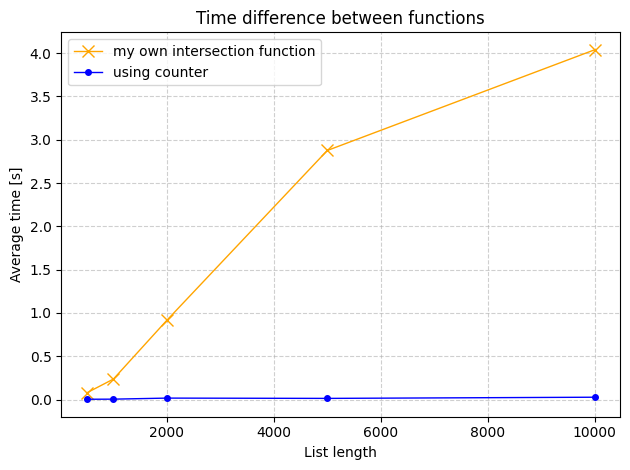

In [55]:
import random
import timeit
import statistics
import matplotlib.pyplot as plt


def my_own_intersection(list1, list2):
    '''The function returns the intersection of two lists.'''
    dict1 = {i: list1.count(i) for i in set(list1)}
    dict2 = {i: list2.count(i) for i in set(list2)}

    result =[]
    for key in dict1:
        if key in dict2:
            result.extend([key] * min(dict1[key], dict2[key]))            

    return result

def using_counter(list1, list2):
    return list((Counter(list1) & Counter(list2)).elements())

lengths = [500, 1000, 2000, 5000, 10000]
solution1 = []
solution2 = []


for k in lengths:
    random.seed(100)
    A = [random.randint(-1000, 1000) for i in range(k)]
    random.seed(101)
    B = [random.randint(-1000, 1000) for i in range(k)]
    solution1.append(statistics.mean(timeit.repeat(lambda: my_own_intersection(A.copy(), B.copy()), repeat=2, number=10)))
    solution2.append(statistics.mean(timeit.repeat(lambda: using_counter(A.copy(), B.copy()), repeat=2, number=10)))

# Plot the graph to combine above results
plt.plot(lengths, solution1, marker='x', label='my own intersection function', color='orange', ms=8, lw=1)
plt.plot(lengths, solution2, marker='o', label='using counter', color='blue', ms=4, lw=1)
plt.title('Time difference between functions')
plt.xlabel('List length')
plt.ylabel('Average time [s]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()